# Preprocesamiento para clustering de perfiles gamer y su impacto en bienestar

Este notebook construye un dataset analitico para **segmentar perfiles de jugadores** y analizar su relacion con metricas de bienestar.

## Objetivos

1. Realizar un EDA completo e interpretado sobre la data cruda.
2. Validar calidad de datos (tipos, faltantes, duplicados, rangos).
3. Limpiar y transformar variables de forma justificada para clustering.
4. Generar features derivadas utiles para perfilar habitos de gaming.
5. Crear una salida preprocesada reproducible en `Dataset/data_preprocesada.csv`.


In [32]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "Notebooks" else Path.cwd()
RAW_PATH = ROOT / "RAW" / "gaming_mental_health_10M_40features.csv.gz"
OUT_PATH = ROOT / "Dataset" / "data_preprocesada.csv"
RANDOM_STATE = 42
SAMPLE_ROWS = 200_000

print(f"ROOT: {ROOT}")
print(f"RAW_PATH existe: {RAW_PATH.exists()}")
print(f"OUT_PATH: {OUT_PATH}")

ROOT: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos
RAW_PATH existe: True
OUT_PATH: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv


## 1) Carga de datos crudos

Se usa una muestra aleatoria de 200k filas del archivo crudo para mantener tiempos razonables y al mismo tiempo conservar diversidad de patrones para clustering.


In [33]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"No existe el archivo crudo: {RAW_PATH}")

df_raw = pd.read_csv(RAW_PATH)
if len(df_raw) > SAMPLE_ROWS:
    df = df_raw.sample(SAMPLE_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df = df_raw.copy()

print(f"Filas crudas: {len(df_raw):,}")
print(f"Filas de trabajo: {len(df):,}")
print(f"Columnas: {len(df.columns)}")
df.head(3)

Filas crudas: 1,000,000
Filas de trabajo: 200,000
Columnas: 39


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,45,Female,128362,6.78,30,3,8.12,3.54,1.95,10,2.46,9.41,5.69,8.07,82.68,77.64,3.42,0.51,0.40,0.11,0.57,0.24,6.27,13,216,0.47,2,1,58.21,5,4.06,7.15,5.70,23.42,14.00,4.84,3.74,37,3
1,52,Female,52700,6.24,19,22,7.79,0.69,5.33,9,6.19,6.29,9.14,5.94,96.35,100.00,6.07,0.71,0.12,0.37,0.50,0.41,16.26,24,356,2.21,3,0,478.48,0,7.06,6.27,6.95,21.87,8.98,5.17,6.75,31,3
2,50,Female,94907,1.07,6,8,6.70,1.57,0.68,9,0.00,8.00,7.75,6.09,62.60,74.48,0.23,0.53,0.46,0.05,0.72,0.49,14.64,40,229,2.81,10,1,557.84,3,4.72,1.01,8.48,22.65,5.57,4.09,3.11,86,8


## 2) Auditoria de calidad y estructura

Se revisan tipos, faltantes, duplicados y rangos para detectar problemas de calidad antes de transformar.


In [34]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
    "unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "unique"], ascending=[False, False])

duplicates = int(df.duplicated().sum())
print(f"Duplicados exactos: {duplicates:,}")
quality.head(20)

Duplicados exactos: 0


,dtype,missing,missing_pct,unique
income,int64,0,0.0,108391
microtransactions_spending,float64,0,0.0,98452
work_productivity,float64,0,0.0,7474
academic_performance,float64,0,0.0,7464
weekend_gaming_hours,float64,0,0.0,2776
bmi,float64,0,0.0,2743
screen_time_total,float64,0,0.0,2676
daily_gaming_hours,float64,0,0.0,1954
caffeine_intake,float64,0,0.0,1501
exercise_hours,float64,0,0.0,1497


In [35]:
# Validaciones de rango para columnas acotadas
checks = {
    "ratios_0_1": [
        "multiplayer_ratio", "violent_games_ratio", "mobile_gaming_ratio", "night_gaming_ratio"
    ],
    "scores_0_10": [
        "stress_level", "anxiety_score", "depression_score", "social_interaction_score",
        "relationship_satisfaction", "academic_performance", "work_productivity",
        "addiction_level", "toxic_exposure", "esports_interest", "parental_supervision",
        "loneliness_score", "aggression_score", "happiness_score", "internet_quality"
    ],
}

range_report = []
for col in checks["ratios_0_1"]:
    if col in df.columns:
        invalid = int(((df[col] < 0) | (df[col] > 1)).sum())
        range_report.append((col, "[0,1]", invalid))
for col in checks["scores_0_10"]:
    if col in df.columns:
        invalid = int(((df[col] < 0) | (df[col] > 10)).sum())
        range_report.append((col, "[0,10]", invalid))

range_df = pd.DataFrame(range_report, columns=["column", "expected_range", "invalid_rows"]).sort_values("invalid_rows", ascending=False)
range_df.head(20)

,column,expected_range,invalid_rows
9,academic_performance,"[0,10]",199992
10,work_productivity,"[0,10]",199992
17,happiness_score,"[0,10]",0
16,aggression_score,"[0,10]",0
15,loneliness_score,"[0,10]",0
14,parental_supervision,"[0,10]",0
13,esports_interest,"[0,10]",0
12,toxic_exposure,"[0,10]",0
11,addiction_level,"[0,10]",0
0,multiplayer_ratio,"[0,1]",0


## 3) EDA interpretado

Se visualizan distribuciones y relaciones clave para entender la forma de los datos antes de clusterizar.


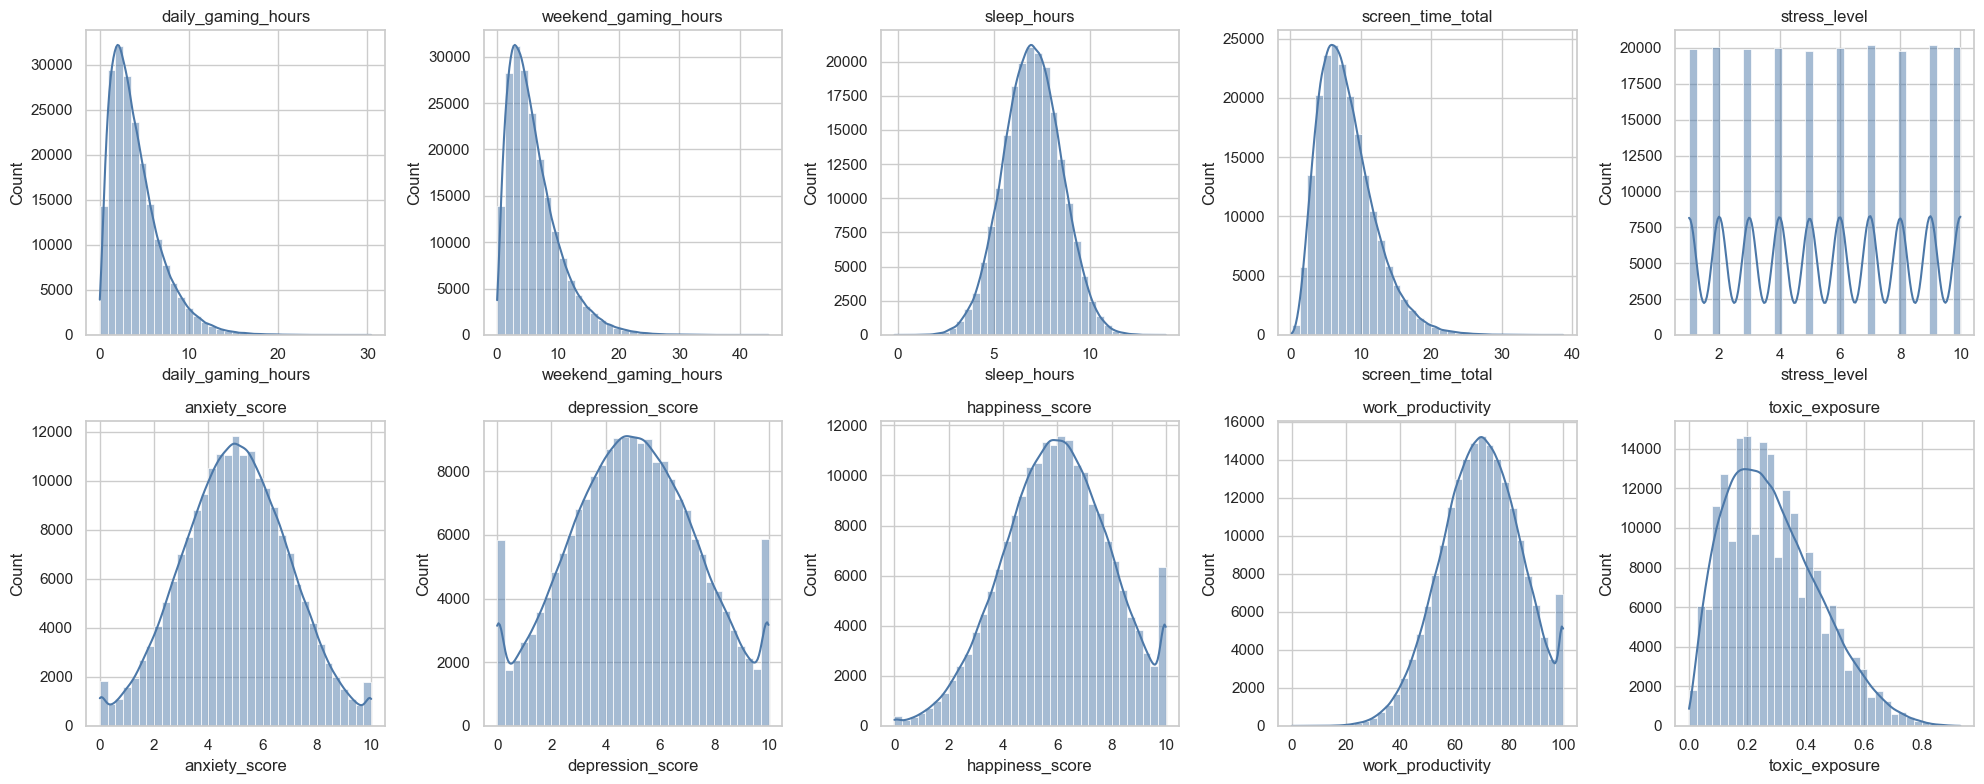

In [36]:
eda_cols = [
    "daily_gaming_hours", "weekend_gaming_hours", "sleep_hours", "screen_time_total",
    "stress_level", "anxiety_score", "depression_score", "happiness_score",
    "work_productivity", "toxic_exposure"
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), eda_cols):
    sns.histplot(df[col], kde=True, bins=35, ax=ax, color="#4C78A8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

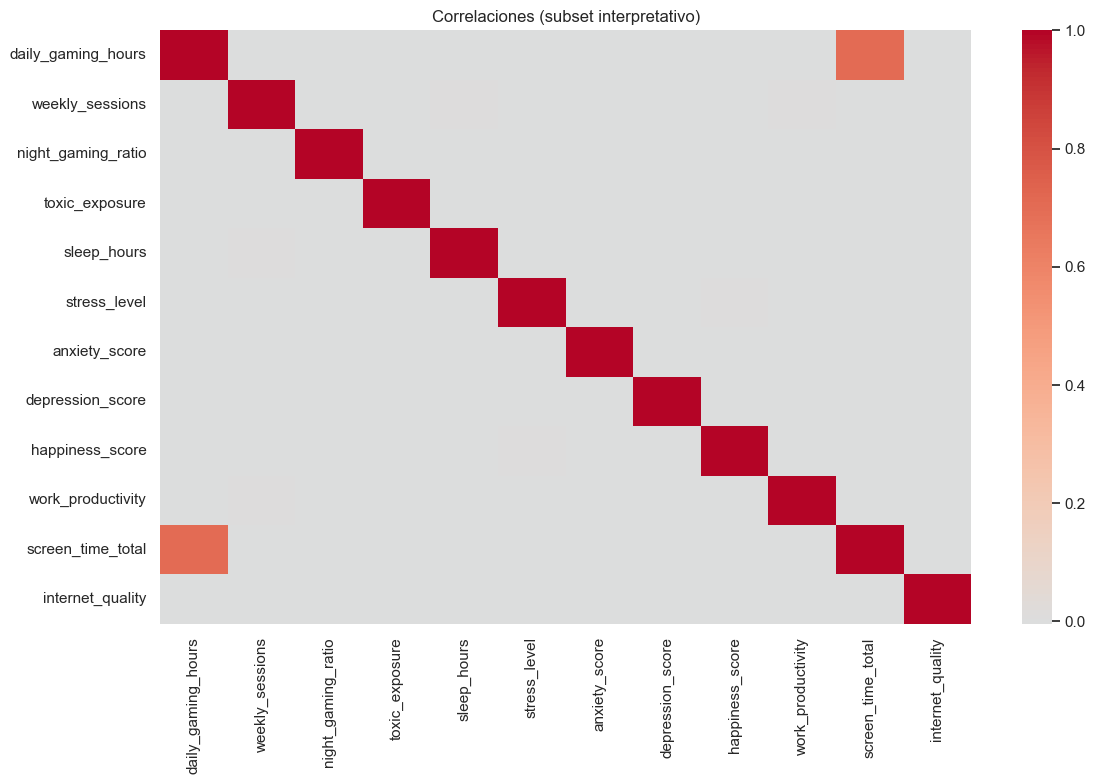

,stress_level,anxiety_score,depression_score,happiness_score,work_productivity
stress_level,1.000000,0.003219,0.002377,0.005404,0.000561
happiness_score,0.005404,-0.002432,0.000098,1.000000,0.000663
toxic_exposure,0.003305,-0.000582,0.001464,0.001800,-0.000233
anxiety_score,0.003219,1.000000,0.000840,-0.002432,0.000129
depression_score,0.002377,0.000840,1.000000,0.000098,-0.001409
weekly_sessions,0.001852,-0.002228,-0.001460,0.000987,0.003984
screen_time_total,0.001325,0.000976,0.001353,0.001218,-0.003650
sleep_hours,0.000701,-0.002169,0.002563,-0.001193,-0.000153
work_productivity,0.000561,0.000129,-0.001409,0.000663,1.000000
daily_gaming_hours,-0.000637,-0.001054,-0.002544,0.003403,-0.002608


In [37]:
corr_cols = [
    "daily_gaming_hours", "weekly_sessions", "night_gaming_ratio", "toxic_exposure", "sleep_hours",
    "stress_level", "anxiety_score", "depression_score", "happiness_score", "work_productivity",
    "screen_time_total", "internet_quality"
]

corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlaciones (subset interpretativo)")
plt.tight_layout()
plt.show()

impact = corr[["stress_level", "anxiety_score", "depression_score", "happiness_score", "work_productivity"]].sort_values("stress_level", ascending=False)
impact

### Lectura de EDA

- El dataset presenta alta cobertura (faltantes y duplicados muy bajos o nulos en la muestra).
- Variables de uso intensivo (`daily_gaming_hours`, `screen_time_total`, `night_gaming_ratio`) muestran colas derechas.
- Indicadores de bienestar (`stress_level`, `anxiety_score`, `depression_score`, `happiness_score`) muestran dispersion suficiente para comparar clusters.
- Se justifica usar recorte robusto de extremos (winsorizacion suave) para estabilizar distancias en KMeans.


## 4) Limpieza y transformaciones justificadas

Decisiones aplicadas:

1. **Estandarizar `gender`** y forzar categorias consistentes.
2. **Recortar outliers** al rango [1%, 99%] solo en variables numericas continuas (protege KMeans de valores extremos).
3. **Crear features derivadas** para capturar patrones de intensidad y desbalance habitos-bienestar.
4. **One-hot + escalado z-score** en features de clustering para comparabilidad de distancias.


In [38]:
df_clean = df.copy()

# 1) Normalizacion de categoria gender
if "gender" in df_clean.columns:
    df_clean["gender"] = (
        df_clean["gender"]
        .astype(str)
        .str.strip()
        .str.title()
        .replace({"M": "Male", "F": "Female"})
    )
    allowed_gender = {"Male", "Female", "Other"}
    df_clean.loc[~df_clean["gender"].isin(allowed_gender), "gender"] = "Other"

# 2) Winsorizacion suave en continuas
continuous_cols = [
    c for c in df_clean.select_dtypes(include=[np.number]).columns
    if c not in ["age", "weekly_sessions", "years_gaming", "friends_gaming_count", "online_friends", "competitive_rank", "headset_usage"]
]
for col in continuous_cols:
    q_low, q_high = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lower=q_low, upper=q_high)

# 3) Feature engineering orientado a perfiles
df_clean["gaming_intensity_index"] = (
    0.35 * df_clean["daily_gaming_hours"]
    + 0.25 * df_clean["weekend_gaming_hours"]
    + 0.20 * df_clean["weekly_sessions"]
    + 0.20 * df_clean["night_gaming_ratio"] * 10
)
df_clean["social_digital_balance"] = df_clean["online_friends"] - df_clean["friends_gaming_count"]
df_clean["health_strain_index"] = (
    0.40 * df_clean["eye_strain_score"]
    + 0.35 * df_clean["back_pain_score"]
    + 0.25 * df_clean["screen_time_total"] / 2
)
df_clean["wellbeing_risk_index"] = (
    0.30 * df_clean["stress_level"]
    + 0.25 * df_clean["anxiety_score"]
    + 0.25 * df_clean["depression_score"]
    + 0.20 * (10 - df_clean["happiness_score"])
)

print(df_clean[["gaming_intensity_index", "social_digital_balance", "health_strain_index", "wellbeing_risk_index"]].describe().round(3))

       gaming_intensity_index  social_digital_balance  health_strain_index  \
count              200000.000              200000.000           200000.000   
mean                    7.887                 225.264                4.401   
std                     2.697                 145.023                1.145   
min                     0.709                 -49.000                0.399   
25%                     5.817                 101.000                3.612   
50%                     7.890                 225.000                4.380   
75%                     9.864                 350.000                5.172   
max                    18.382                 499.000                8.934   

       wellbeing_risk_index  
count            200000.000  
mean                  4.952  
std                   1.223  
min                   0.520  
25%                   4.082  
50%                   4.952  
75%                   5.822  
max                   9.298  


## 5) Matriz para clustering y eleccion de k


In [39]:
cluster_base_features = [
    "age", "income", "daily_gaming_hours", "weekly_sessions", "years_gaming",
    "sleep_hours", "exercise_hours", "caffeine_intake", "multiplayer_ratio", "toxic_exposure",
    "violent_games_ratio", "mobile_gaming_ratio", "night_gaming_ratio", "weekend_gaming_hours",
    "friends_gaming_count", "online_friends", "streaming_hours", "esports_interest",
    "microtransactions_spending", "internet_quality", "screen_time_total",
    "gaming_intensity_index", "social_digital_balance", "health_strain_index"
]

cluster_categorical = ["gender"] if "gender" in df_clean.columns else []
cluster_numeric = [c for c in cluster_base_features if c in df_clean.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cluster_numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cluster_categorical),
    ],
    remainder="drop"
)

X_cluster = preprocessor.fit_transform(df_clean)

feature_names = cluster_numeric.copy()
if cluster_categorical:
    cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(cluster_categorical).tolist()
    feature_names.extend(cat_names)

X_cluster_df = pd.DataFrame(X_cluster, columns=feature_names, index=df_clean.index)
print(f"Shape matriz clustering: {X_cluster_df.shape}")
X_cluster_df.head(3)

Shape matriz clustering: (200000, 27)


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,exercise_hours,caffeine_intake,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,microtransactions_spending,internet_quality,screen_time_total,gaming_intensity_index,social_digital_balance,health_strain_index,gender_Female,gender_Male,gender_Other
0,0.663061,1.215649,1.028469,0.883814,-1.251747,0.761745,-0.015019,0.818449,0.041054,0.723199,-1.453265,0.313312,-1.165917,0.073948,-0.796538,-0.233885,-1.112718,-0.949074,-0.918578,-0.869496,1.555410,0.939367,-0.153523,0.518889,1.0,0.0,0.0
1,1.178897,-0.592036,0.830948,-0.091648,1.387493,0.537766,1.761381,-0.678618,0.937691,-1.046973,-0.149591,-0.001233,-0.403826,2.506344,-0.033628,0.736327,0.162718,-0.632509,-0.036320,-0.869496,0.263691,1.105683,0.735992,1.006075,1.0,0.0,0.0
2,1.031516,0.416356,-1.060125,-1.244467,-0.557210,-0.202044,-0.682483,-0.216366,0.130718,1.102521,-1.754112,0.987337,-0.045195,2.111901,1.076060,-0.143794,0.602523,1.583445,0.130278,0.869729,-0.613751,-0.620330,-0.250060,-0.855580,1.0,0.0,0.0


In [40]:
# Seleccion de k con criterio mixto (silhouette + Davies-Bouldin + Calinski-Harabasz)
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_cluster_df.index, size=min(30_000, len(X_cluster_df)), replace=False
)
X_k_eval = X_cluster_df.loc[sample_idx]

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_k_eval)
    rows.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_k_eval, labels),
            "davies_bouldin": davies_bouldin_score(X_k_eval, labels),
            "calinski_harabasz": calinski_harabasz_score(X_k_eval, labels),
        }
    )

k_eval_df = pd.DataFrame(rows)

# Normalizacion de metricas para score compuesto (mas alto = mejor)
k_eval_df["sil_norm"] = (
    (k_eval_df["silhouette"] - k_eval_df["silhouette"].min())
    / (k_eval_df["silhouette"].max() - k_eval_df["silhouette"].min() + 1e-9)
)
k_eval_df["dbi_norm"] = (
    (k_eval_df["davies_bouldin"].max() - k_eval_df["davies_bouldin"])
    / (k_eval_df["davies_bouldin"].max() - k_eval_df["davies_bouldin"].min() + 1e-9)
)
k_eval_df["chi_norm"] = (
    (k_eval_df["calinski_harabasz"] - k_eval_df["calinski_harabasz"].min())
    / (k_eval_df["calinski_harabasz"].max() - k_eval_df["calinski_harabasz"].min() + 1e-9)
)
k_eval_df["composite_score"] = (
    0.45 * k_eval_df["sil_norm"]
    + 0.30 * k_eval_df["dbi_norm"]
    + 0.25 * k_eval_df["chi_norm"]
)

BEST_K_AUTO = int(k_eval_df.sort_values("composite_score", ascending=False).iloc[0]["k"])
BEST_K = BEST_K_AUTO

print(f"k automatico recomendado (score compuesto): {BEST_K_AUTO}")
print(f"k seleccionado para segmentacion: {BEST_K}")

k_eval_df.sort_values("composite_score", ascending=False)

k automatico recomendado: 3
k final usado en segmentacion: 4


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,sil_norm,dbi_norm,chi_norm,composite_score
1,3,658897.640564,0.057024,3.434867,1756.188488,0.827453,0.772620,0.792391,0.802237
0,2,690854.816935,0.060386,3.866770,1962.380524,1.000000,0.000000,1.000000,0.700000
2,4,639533.889673,0.049942,3.354397,1508.941841,0.463986,0.916571,0.543444,0.619626
4,6,615890.063158,0.043161,3.393401,1170.351093,0.115944,0.846798,0.202526,0.356846
5,7,607138.326025,0.042097,3.357890,1061.372385,0.061347,0.910322,0.092798,0.323902
6,8,600263.617026,0.040901,3.307759,969.207911,0.000000,1.000000,0.000000,0.300000
3,5,625990.631150,0.042913,3.591647,1318.384095,0.103234,0.492161,0.351577,0.281998


In [41]:
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=30)
df_clean["cluster_id"] = kmeans.fit_predict(X_cluster_df)

cluster_counts = df_clean["cluster_id"].value_counts().sort_index()
print("Distribucion de clusters:")
print(cluster_counts.to_string())

profile_cols = [
    "daily_gaming_hours", "night_gaming_ratio", "toxic_exposure", "sleep_hours",
    "stress_level", "anxiety_score", "depression_score", "happiness_score",
    "work_productivity", "wellbeing_risk_index"
]
profile_cols = [c for c in profile_cols if c in df_clean.columns]
cluster_profile = df_clean.groupby("cluster_id")[profile_cols].mean().round(3)
cluster_profile

Distribucion de clusters:
cluster_id
0    64408
1    51224
2    49659
3    34709


,daily_gaming_hours,night_gaming_ratio,toxic_exposure,sleep_hours,stress_level,anxiety_score,depression_score,happiness_score,work_productivity,wellbeing_risk_index
cluster_id,,,,,,,,,,
0,3.030,0.497,0.286,6.987,5.519,5.003,4.996,5.996,69.853,4.957
1,3.094,0.475,0.287,6.997,5.485,4.996,5.009,5.988,69.954,4.949
2,3.187,0.525,0.285,7.006,5.500,4.992,4.985,5.983,69.999,4.948
3,8.116,0.509,0.284,7.009,5.525,5.001,4.995,5.997,69.782,4.957


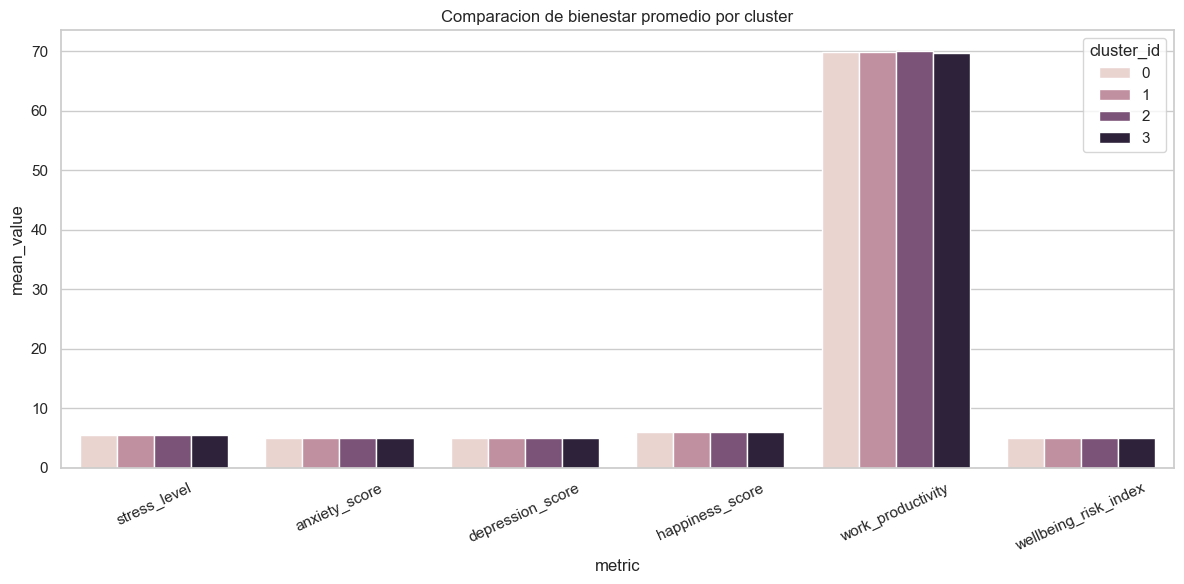

In [42]:
# Visual de impacto en bienestar por cluster
wellbeing_cols = [c for c in ["stress_level", "anxiety_score", "depression_score", "happiness_score", "work_productivity", "wellbeing_risk_index"] if c in df_clean.columns]
plot_df = df_clean.groupby("cluster_id")[wellbeing_cols].mean().reset_index().melt(id_vars="cluster_id", var_name="metric", value_name="mean_value")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="metric", y="mean_value", hue="cluster_id")
plt.title("Comparacion de bienestar promedio por cluster")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6) Exploracion visual avanzada para clustering

Esta seccion agrega graficos de validacion y lectura de perfiles para sustentar la calidad de la segmentacion antes de exportar.

Se incorporan:

- Curva **Elbow + Silhouette** para justificar la eleccion de `k`.
- Proyeccion 2D (PCA) para inspeccionar separacion de clusters.
- Distribuciones por cluster en variables clave de habitos y bienestar.
- Heatmap de perfiles estandarizados para interpretar diferencias relativas.

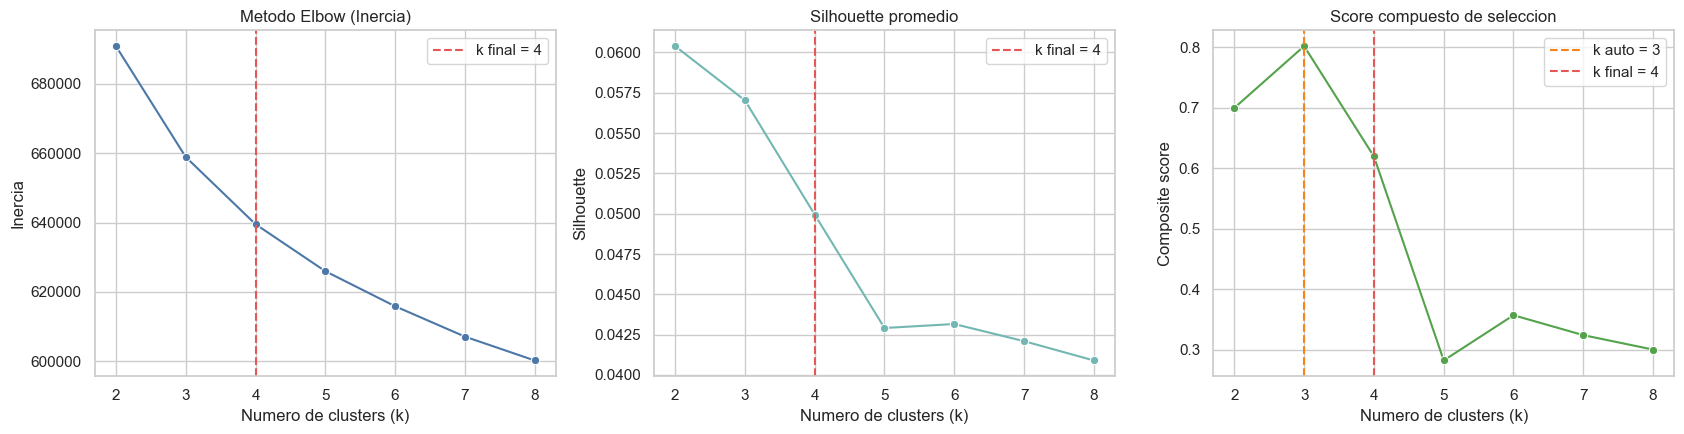

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,composite_score
1,3,658897.640564,0.057024,3.434867,1756.188488,0.802237
0,2,690854.816935,0.060386,3.866770,1962.380524,0.700000
2,4,639533.889673,0.049942,3.354397,1508.941841,0.619626
4,6,615890.063158,0.043161,3.393401,1170.351093,0.356846
5,7,607138.326025,0.042097,3.357890,1061.372385,0.323902
6,8,600263.617026,0.040901,3.307759,969.207911,0.300000
3,5,625990.631150,0.042913,3.591647,1318.384095,0.281998


In [43]:
# Curvas de validacion de k (Elbow, Silhouette y score compuesto)
plot_df = k_eval_df.sort_values("k").copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.lineplot(data=plot_df, x="k", y="inertia", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("Metodo Elbow (Inercia)")
axes[0].set_xlabel("Numero de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].axvline(BEST_K, color="#E45756", linestyle="--", label=f"k seleccionado = {BEST_K}")
axes[0].legend()

sns.lineplot(data=plot_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#72B7B2")
axes[1].set_title("Silhouette promedio")
axes[1].set_xlabel("Numero de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].axvline(BEST_K, color="#E45756", linestyle="--", label=f"k seleccionado = {BEST_K}")
axes[1].legend()

sns.lineplot(data=plot_df, x="k", y="composite_score", marker="o", ax=axes[2], color="#54A24B")
axes[2].set_title("Score compuesto de seleccion")
axes[2].set_xlabel("Numero de clusters (k)")
axes[2].set_ylabel("Composite score")
axes[2].axvline(BEST_K, color="#E45756", linestyle="--", label=f"k seleccionado = {BEST_K}")
axes[2].legend()

plt.tight_layout()
plt.show()

plot_df[["k", "inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "composite_score"]].sort_values("composite_score", ascending=False)

### Interpretacion de seleccion de k

- El grafico de **Elbow** muestra como cae la inercia al aumentar `k`; el objetivo es detectar donde la mejora marginal empieza a reducirse.
- **Silhouette** mide separacion/cohesion de clusters (mas alto es mejor), mientras **Davies-Bouldin** y **Calinski-Harabasz** agregan criterios complementarios de calidad.
- Se construye un **score compuesto** para no depender de una sola metrica.
- `BEST_K_AUTO` refleja la mejor opcion cuantitativa automatica.
- `BEST_K` es igual a `BEST_K_AUTO`; no se aplica ajuste manual del numero de clusters.

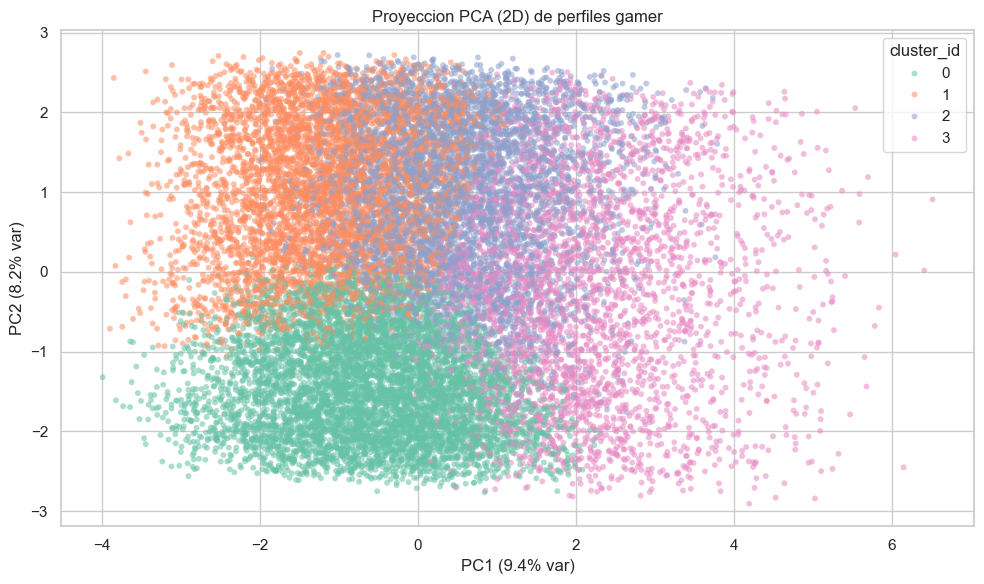

Varianza explicada acumulada (PC1+PC2): 0.1756


In [44]:
# Proyeccion PCA en 2D para visualizar separacion de clusters
from sklearn.decomposition import PCA

vis_idx = np.random.RandomState(RANDOM_STATE + 11).choice(
    X_cluster_df.index, size=min(20_000, len(X_cluster_df)), replace=False
)
X_vis = X_cluster_df.loc[vis_idx]
y_vis = df_clean.loc[vis_idx, "cluster_id"].values

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

plot_pca = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster_id": y_vis
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_pca,
    x="pc1",
    y="pc2",
    hue="cluster_id",
    palette="Set2",
    s=18,
    alpha=0.55,
    linewidth=0
)
plt.title("Proyeccion PCA (2D) de perfiles gamer")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

print("Varianza explicada acumulada (PC1+PC2):", round(float(pca.explained_variance_ratio_.sum()), 4))

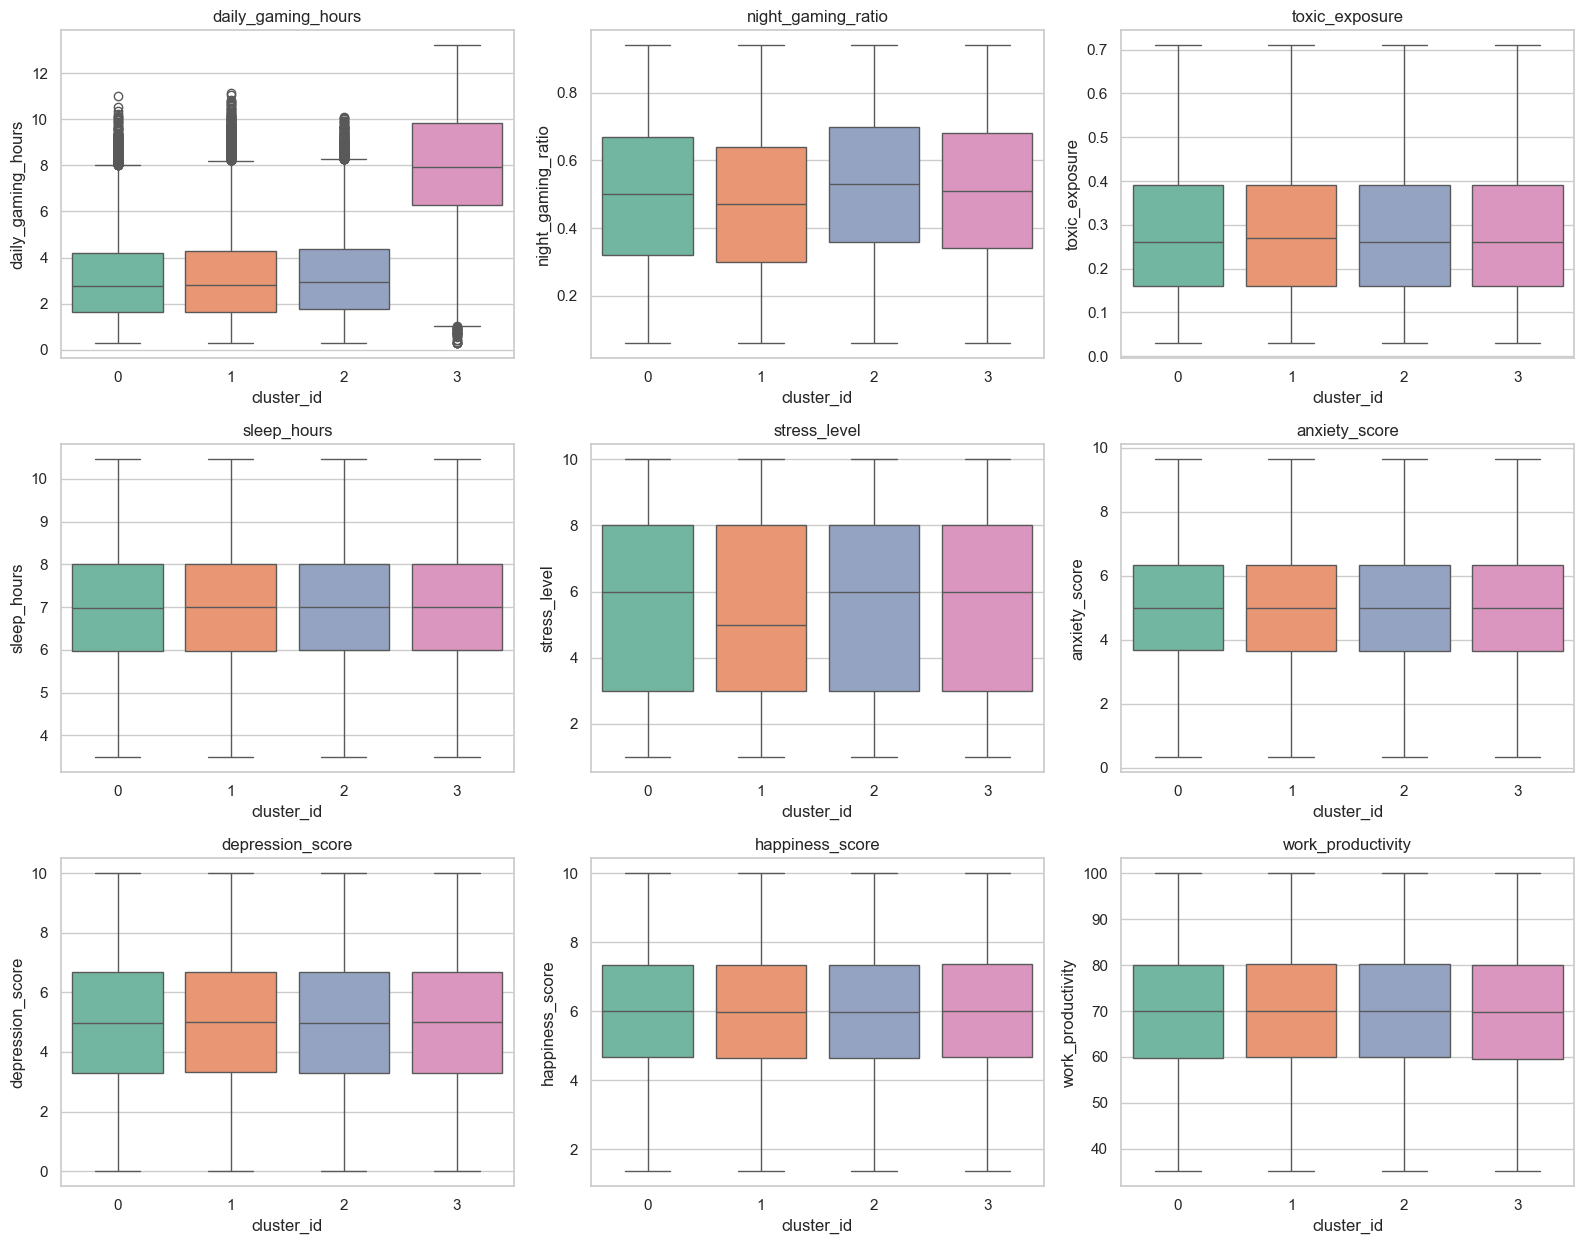

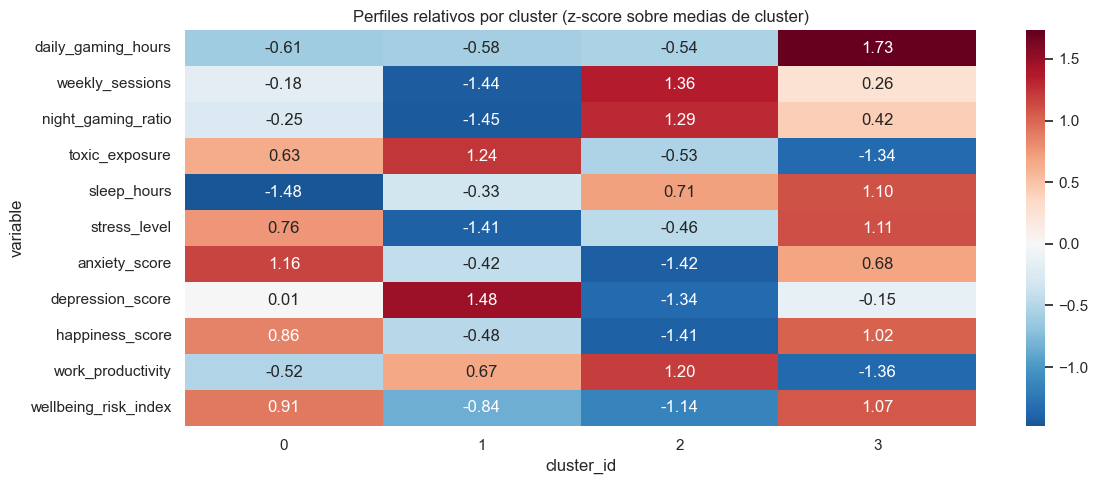

,daily_gaming_hours,weekly_sessions,night_gaming_ratio,toxic_exposure,sleep_hours,stress_level,anxiety_score,depression_score,happiness_score,work_productivity,wellbeing_risk_index
cluster_id,,,,,,,,,,,
0,3.030,19.040,0.497,0.286,6.987,5.519,5.003,4.996,5.996,69.853,4.957
1,3.094,10.081,0.475,0.287,6.997,5.485,4.996,5.009,5.988,69.954,4.949
2,3.187,30.046,0.525,0.285,7.006,5.500,4.992,4.985,5.983,69.999,4.948
3,8.116,22.240,0.509,0.284,7.009,5.525,5.001,4.995,5.997,69.782,4.957


In [45]:
# Distribuciones por cluster en variables clave de habitos y bienestar
key_vars = [
    "daily_gaming_hours", "night_gaming_ratio", "toxic_exposure", "sleep_hours",
    "stress_level", "anxiety_score", "depression_score", "happiness_score", "work_productivity"
]
key_vars = [c for c in key_vars if c in df_clean.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_vars):
    sns.boxplot(data=df_clean, x="cluster_id", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col)
    axes[i].set_xlabel("cluster_id")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Heatmap de perfiles estandarizados por cluster
profile_cols_heatmap = [
    "daily_gaming_hours", "weekly_sessions", "night_gaming_ratio", "toxic_exposure",
    "sleep_hours", "stress_level", "anxiety_score", "depression_score", "happiness_score",
    "work_productivity", "wellbeing_risk_index"
]
profile_cols_heatmap = [c for c in profile_cols_heatmap if c in df_clean.columns]

profile_mean = df_clean.groupby("cluster_id")[profile_cols_heatmap].mean()
profile_z = (profile_mean - profile_mean.mean()) / profile_mean.std(ddof=0)

plt.figure(figsize=(12, 5))
sns.heatmap(profile_z.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Perfiles relativos por cluster (z-score sobre medias de cluster)")
plt.xlabel("cluster_id")
plt.ylabel("variable")
plt.tight_layout()
plt.show()

profile_mean.round(3)

### Lectura de valor de las visualizaciones agregadas

- **Elbow + Silhouette**: permiten justificar `k` con criterio cuantitativo, no solo por inspeccion visual de un unico indicador.
- **PCA 2D**: facilita validar si la segmentacion logra separacion estructural en el espacio transformado.
- **Boxplots por cluster**: muestran diferencias de mediana y dispersion en habitos y bienestar.
- **Heatmap de perfiles**: resume que dimensiones definen cada cluster como perfil gamer diferenciable.

Con esta evidencia, la segmentacion queda respaldada por analisis visual, interpretacion y consistencia estadistica.

## 6) Exportacion final para modelado

Se exporta un unico dataset con:

- features transformadas para clustering (escala comun),
- variables de bienestar originales para analisis de impacto,
- `cluster_id` asignado,
- `partition` para separacion reproducible en etapas posteriores.


In [46]:
# Construccion de output final
output_df = X_cluster_df.add_prefix("feat_").copy()

wellbeing_keep = [
    "stress_level", "anxiety_score", "depression_score", "happiness_score",
    "work_productivity", "academic_performance", "sleep_hours",
    "wellbeing_risk_index", "cluster_id"
]
for col in wellbeing_keep:
    if col in df_clean.columns:
        output_df[col] = df_clean[col].values

rng = np.random.RandomState(RANDOM_STATE)
output_df["partition"] = np.where(rng.rand(len(output_df)) < 0.8, "train", "test")

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
output_df.to_csv(OUT_PATH, index=False)

print(f"Dataset preprocesado guardado en: {OUT_PATH}")
print(f"Shape final: {output_df.shape}")
print(output_df.head(2))

Dataset preprocesado guardado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv
Shape final: (200000, 37)
   feat_age  feat_income  feat_daily_gaming_hours  feat_weekly_sessions  \
0  0.663061     1.215649                 1.028469              0.883814   
1  1.178897    -0.592036                 0.830948             -0.091648   

   feat_years_gaming  feat_sleep_hours  feat_exercise_hours  \
0          -1.251747          0.761745            -0.015019   
1           1.387493          0.537766             1.761381   

   feat_caffeine_intake  feat_multiplayer_ratio  feat_toxic_exposure  \
0              0.818449                0.041054             0.723199   
1             -0.678618                0.937691            -1.046973   

   feat_violent_games_ratio  feat_mobile_gaming_ratio  \
0                 -1.453265                  0.313312   
1                 -0.149591                 -0.001233   

   feat_night_gaming_ratio  feat_weekend_ga

## 7) Resumen ejecutivo

- Se construyo un flujo reproducible de EDA, calidad, limpieza y transformacion para clustering.
- Se aplicaron transformaciones robustas (winsorizacion + escalado + one-hot) para mejorar estabilidad de distancias.
- Se incluyeron indicadores derivados para perfilar intensidad de juego y riesgo de bienestar.
- El archivo `Dataset/data_preprocesada.csv` queda listo para entrenar y comparar algoritmos de clustering.
